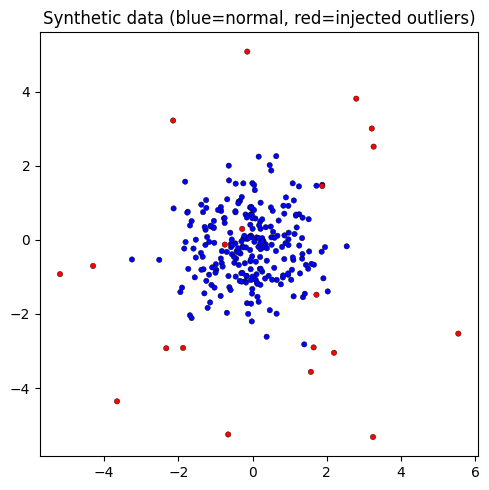

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest as SkIsolationForest
from sklearn.metrics import classification_report
from scipy.stats import spearmanr

from isolation_forest import IsolationForest, c

rng = np.random.default_rng(7)
normal = rng.normal(loc=(0, 0), scale=1.0, size=(250, 2))
outliers = rng.uniform(-6, 6, size=(20, 2))
X = np.vstack([normal, outliers])
y_true = np.array([1] * 250 + [-1] * 20)  # 1 = inlier, -1 = outlier (sklearn convention)

plt.figure(figsize=(5, 5))
plt.scatter(X[:, 0], X[:, 1], c=["b" if l == 1 else "r" for l in y_true], s=15, edgecolor="k", linewidth=0.3)
plt.title("Synthetic data (blue=normal, red=injected outliers)")
plt.tight_layout()
plt.show()

In [2]:
sk_forest = SkIsolationForest(n_estimators=200, max_samples=128, contamination=0.07, random_state=0)
sk_forest.fit(X)
sk_pred = sk_forest.predict(X)

print(classification_report(y_true, sk_pred, digits=3))

              precision    recall  f1-score   support

          -1      0.842     0.800     0.821        20
           1      0.984     0.988     0.986       250

    accuracy                          0.974       270
   macro avg      0.913     0.894     0.903       270
weighted avg      0.974     0.974     0.974       270



In [3]:
forest = IsolationForest(n_trees=200, subsample_size=128, contamination=0.07, seed=0)
forest.fit(X)
my_pred = forest.predict(X)

print(classification_report(y_true, my_pred, digits=3))

              precision    recall  f1-score   support

          -1      0.842     0.800     0.821        20
           1      0.984     0.988     0.986       250

    accuracy                          0.974       270
   macro avg      0.913     0.894     0.903       270
weighted avg      0.974     0.974     0.974       270



Spearman correlation between score rankings: 0.985
Label agreement with sklearn:                1.000


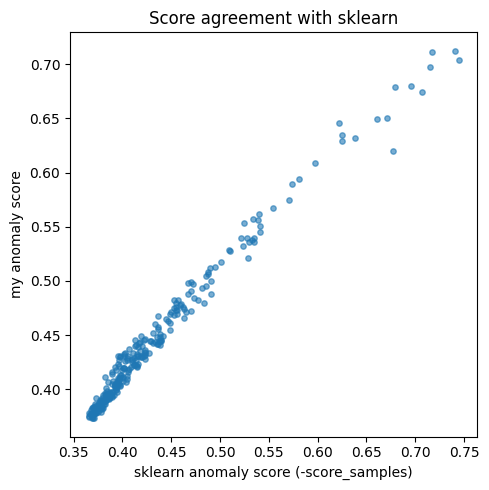

In [4]:
sk_score = -sk_forest.score_samples(X)  # flip sign: higher = more anomalous, matches our convention
my_score = forest.anomaly_score(X)

corr, _ = spearmanr(sk_score, my_score)
agreement = (sk_pred == my_pred).mean()

print(f"Spearman correlation between score rankings: {corr:.3f}")
print(f"Label agreement with sklearn:                {agreement:.3f}")

plt.figure(figsize=(5, 5))
plt.scatter(sk_score, my_score, s=15, alpha=0.6)
plt.xlabel("sklearn anomaly score (-score_samples)")
plt.ylabel("my anomaly score")
plt.title("Score agreement with sklearn")
plt.tight_layout()
plt.show()

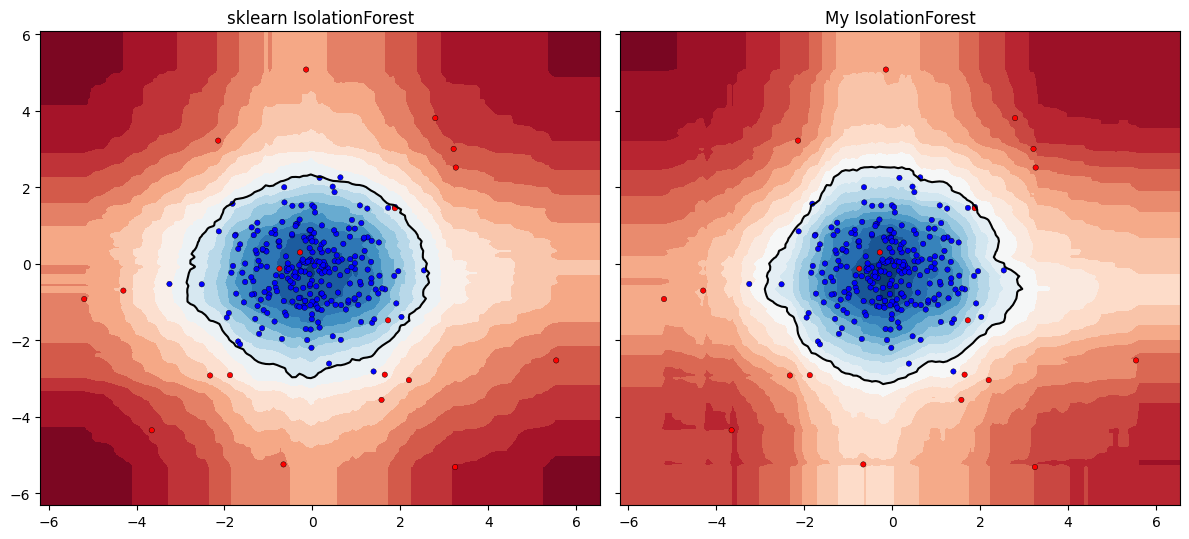

In [5]:
pad = 1
x_min, x_max = X[:, 0].min() - pad, X[:, 0].max() + pad
y_min, y_max = X[:, 1].min() - pad, X[:, 1].max() + pad
xv, yv = np.meshgrid(np.linspace(x_min, x_max, 150), np.linspace(y_min, y_max, 150))
grid = np.c_[xv.ravel(), yv.ravel()]

Z_sk = sk_forest.decision_function(grid).reshape(xv.shape)
Z_my = forest.decision_function(grid).reshape(xv.shape)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharex=True, sharey=True)
for ax, Z, title in zip(axes, [Z_sk, Z_my], ["sklearn IsolationForest", "My IsolationForest"]):
    ax.contourf(xv, yv, Z, levels=20, cmap="RdBu")
    ax.contour(xv, yv, Z, levels=[0], colors="k", linewidths=1.5)  # decision boundary
    ax.scatter(X[:, 0], X[:, 1], c=["b" if l == 1 else "r" for l in y_true], s=15, edgecolor="k", linewidth=0.3)
    ax.set_title(title)

plt.tight_layout()
plt.show()